In [2]:
import aeolis
from tkinter import *
from tkinter import ttk, filedialog, Canvas
import os
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import numpy as np

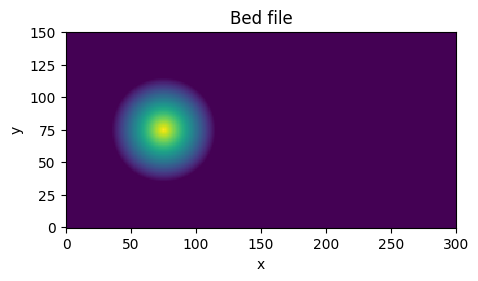

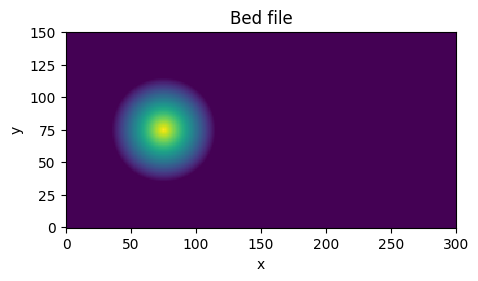

In [3]:

# Default configuration file path
configfile = r'C:\Users\svries\Documents\GitHub\OE_aeolis-python\aeolis\examples\2D\Barchan_dune\aeolis.txt'

# Function to prompt the user to select a configuration file
def prompt_file():
    file_path = filedialog.askopenfilename(
        initialdir=os.path.dirname(configfile),
        title="Select config file",
        filetypes=(("Text files", "*.txt"), ("All files", "*.*"))
    )
    return file_path if file_path else configfile

# Prompt the user to select a configuration file or use the default
configfile = prompt_file()
# Read the configuration file into a dictionary
dic = aeolis.inout.read_configfile(configfile)

class AeolisGUI:
    def __init__(self, root, dic):
        self.root = root
        self.dic = dic
        self.root.title('Aeolis')
        self.create_widgets()     

    def create_widgets(self):
        # Create a tab control widget
        tab_control = ttk.Notebook(self.root)
        # Create individual tabs
        self.create_domain_tab(tab_control)
        self.create_timeframe_tab(tab_control)
        self.create_boundary_conditions_tab(tab_control)
        self.create_sediment_transport_tab(tab_control)
        # Pack the tab control to expand and fill the available space
        tab_control.pack(expand=1, fill='both')


    def create_label_entry(self, tab, text, value, row):
        # Create a label and entry widget for a given tab
        label = ttk.Label(tab, text=text)
        label.grid(row=row, column=0, padx=20, sticky=W)
        entry = ttk.Entry(tab)
        entry.insert(0, str(value))
        entry.grid(row=row, column=1, sticky=W)
        return entry

    def create_domain_tab(self, tab_control):
        # Create the 'Domain' tab
        tab1 = ttk.Frame(tab_control)
        tab_control.add(tab1, text='Domain')

        # Fields to be displayed in the 'Domain' tab
        fields = ['xgrid_file', 'ygrid_file', 'bed_file', 'ne_file', 'veg_file', 'threshold_file', 'fence_file', 'wave_mask', 'tide_mask', 'threshold_mask']
        # Create label and entry widgets for each field
        self.entries = {field: self.create_label_entry(tab1, f"{field}:", self.dic.get(field, ''), i) for i, field in enumerate(fields)}

        # Create a canvas for displaying figures
        fig_canvas_frame = ttk.Frame(tab1)
        fig_canvas_frame.grid(row=0, column=2, rowspan=20, padx=100, pady=10, sticky=N)
        self.fig_canvas = Canvas(fig_canvas_frame, width=500, height=300, bg='white')
        self.fig_canvas.pack()

        # # Create an 'Update Figure' button
        update_button = ttk.Button(fig_canvas_frame, text="Update Figure", command=self.update_figure)
        update_button.pack()
      
    def create_timeframe_tab(self, tab_control):
        # Create the 'Timeframe' tab
        tab2 = ttk.Frame(tab_control)
        tab_control.add(tab2, text='Timeframe')

        # Fields to be displayed in the 'Timeframe' tab
        fields = ['tstart', 'tstop', 'dt', 'restart', 'refdate']
        # Create label and entry widgets for each field
        self.entries.update({field: self.create_label_entry(tab2, f"{field}:", self.dic.get(field, ''), i) for i, field in enumerate(fields)})

    def create_boundary_conditions_tab(self, tab_control):
        # Create the 'Boundary Conditions' tab
        tab3 = ttk.Frame(tab_control)
        tab_control.add(tab3, text='Boundary Conditions')

        # Fields to be displayed in the 'Boundary Conditions' tab
        fields = ['boundary1', 'boundary2', 'boundary3']
        # Create label and entry widgets for each field
        self.entries.update({field: self.create_label_entry(tab3, f"{field}:", self.dic.get(field, ''), i) for i, field in enumerate(fields)})

    def create_sediment_transport_tab(self, tab_control):
        # Create the 'Sediment Transport' tab
        tab4 = ttk.Frame(tab_control)
        tab_control.add(tab4, text='Sediment Transport')

        # Create a 'Save' button
        save_button = ttk.Button(tab4, text='Save', command=self.save)
        save_button.pack()

    def update_figure(self):       
        # Clear the previous figure
        for widget in self.fig_canvas.winfo_children():
            widget.destroy()
        # Create a new figure
        fig, ax = plt.subplots()

        # Plot the contents of the bed file using imshow
        bed_file_path = os.path.join(os.path.dirname(configfile), str(self.dic['bed_file']))
        bed_data = np.loadtxt(bed_file_path)

        # Use loadtxt to load xgrid_file and ygrid_file
        xgrid_file_path = os.path.join(os.path.dirname(configfile), str(self.dic['xgrid_file']))
        ygrid_file_path = os.path.join(os.path.dirname(configfile), str(self.dic['ygrid_file']))
        xgrid_data = np.loadtxt(xgrid_file_path)
        ygrid_data = np.loadtxt(ygrid_file_path)

        # Use pcolormesh to plot the bed data
        ax.pcolormesh(xgrid_data, ygrid_data, bed_data, shading='auto')
        ax.set_title('Bed file')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
     
        # Embed the figure in the Tkinter canvas
        canvas = FigureCanvasTkAgg(fig, master=self.fig_canvas)
        canvas.draw()

        ax.axis('scaled')
        
        # Get the canvas widget and pack it to fit the existing canvas size with some margin
        canvas_widget = canvas.get_tk_widget()
        canvas_widget.pack(side=TOP, fill=BOTH, expand=1)
        canvas_widget.config(width=self.fig_canvas.winfo_width(), height=self.fig_canvas.winfo_height())

    def save(self):
        # Save the current entries to the configuration dictionary
        for field, entry in self.entries.items():
            self.dic[field] = entry.get()
        # Write the updated configuration to a new file
        aeolis.inout.write_configfile(configfile + '2', self.dic)
        print('Saved!')

if __name__ == "__main__":
    # Create the main application window
    root = Tk()
    # increase the size of the window
    root.geometry("1000x600")

    # Create an instance of the AeolisGUI class
    app = AeolisGUI(root, dic)
    # Start the Tkinter event loop
    root.mainloop()

In [32]:
import aeolis
from tkinter import *
from tkinter import ttk, filedialog
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# Default configuration file path
configfile = r'C:\Users\svries\Documents\GitHub\OE_aeolis-python\aeolis\examples\2D\Barchan_dune\aeolis.txt'

# Function to prompt the user to select a configuration file
def prompt_file():
    file_path = filedialog.askopenfilename(
        initialdir=os.path.dirname(configfile),
        title="Select config file",
        filetypes=(("Text files", "*.txt"), ("All files", "*.*"))
    )
    return file_path if file_path else configfile

# Prompt the user to select a configuration file or use the default
configfile = prompt_file()
# Read the configuration file into a dictionary
dic = aeolis.inout.read_configfile(configfile)

class AeolisGUI:
    def __init__(self, root, dic):
        self.root = root
        self.dic = dic
        self.root.title('Aeolis')
        self.create_widgets()
        # Call update_figure to display the initial figure
        self.update_figure()

    def create_widgets(self):
        # Create a tab control widget
        tab_control = ttk.Notebook(self.root)
        # Create individual tabs
        self.create_domain_tab(tab_control)
        self.create_timeframe_tab(tab_control)
        self.create_boundary_conditions_tab(tab_control)
        self.create_sediment_transport_tab(tab_control)
        # Pack the tab control to expand and fill the available space
        tab_control.pack(expand=1, fill='both')

    def create_label_entry(self, tab, text, value, row):
        # Create a label and entry widget for a given tab
        label = ttk.Label(tab, text=text)
        label.grid(row=row, column=0, sticky=W)
        entry = ttk.Entry(tab)
        entry.insert(0, str(value))
        entry.grid(row=row, column=1, sticky=W)
        return entry

    def create_domain_tab(self, tab_control):
        # Create the 'Domain' tab
        tab1 = ttk.Frame(tab_control)
        tab_control.add(tab1, text='Domain')

        # Fields to be displayed in the 'Domain' tab
        fields = ['xgrid_file', 'ygrid_file', 'bed_file', 'ne_file', 'veg_file', 'threshold_file', 'fence_file', 'wave_mask', 'tide_mask', 'threshold_mask']
        # Create label and entry widgets for each field
        self.entries = {field: self.create_label_entry(tab1, f"{field}:", self.dic.get(field, ''), i) for i, field in enumerate(fields)}

        # Create a frame for figures
        fig_frame = ttk.Frame(tab1)
        fig_frame.grid(row=10, column=0, columnspan=2, pady=10)
        fig_label = ttk.Label(fig_frame, text="Figures:")
        fig_label.pack()

        # Create a canvas for displaying figures
        fig_canvas_frame = ttk.Frame(tab1)
        fig_canvas_frame.grid(row=0, column=2, rowspan=10, padx=10, pady=10, sticky=N)
        self.fig_canvas = Canvas(fig_canvas_frame, width=300, height=200, bg='white')
        self.fig_canvas.pack()

        # Create an 'Update Figure' button
        update_button = ttk.Button(fig_canvas_frame, text="Update Figure", command=self.update_figure)
        update_button.pack()

        # Create a scale slider
        self.scale_var = DoubleVar(value=1.0)
        scale_slider = Scale(fig_canvas_frame, from_=0.5, to=2.0, resolution=0.1, orient=HORIZONTAL, variable=self.scale_var, label="Scale", command=self.update_figure)
        scale_slider.pack()

    def update_figure(self, event=None):
        # Clear the previous figure
        for widget in self.fig_canvas.winfo_children():
            widget.destroy()

        # Get the scale factor from the slider
        scale_factor = self.scale_var.get()

        # Create a new figure with size scaled by the factor
        fig, ax = plt.subplots(figsize=(1.97 * scale_factor, 1.97 * scale_factor))

        # Example xyz data
        x = np.linspace(0, 5, 50)
        y = np.linspace(0, 5, 40)
        X, Y = np.meshgrid(x, y)
        Z = np.sin(X) * np.cos(Y)

        # Create a pseudocolor plot
        c = ax.pcolor(X, Y, Z, cmap='viridis', shading='auto')
        fig.colorbar(c, ax=ax, label='Z value')

        # Set axis to be equal and tight
        ax.axis('equal')
        ax.axis('tight')

        # Embed the figure in the Tkinter canvas
        canvas = FigureCanvasTkAgg(fig, master=self.fig_canvas)
        canvas.draw()
        canvas.get_tk_widget().pack(side=TOP, fill=BOTH, expand=1)

    def save(self):
        # Save the current entries to the configuration dictionary
        for field, entry in self.entries.items():
            self.dic[field] = entry.get()
        # Write the updated configuration to a new file
        aeolis.inout.write_configfile(configfile + '2', self.dic)
        print('Saved!')

if __name__ == "__main__":
    # Create the main application window
    root = Tk()
    # Create an instance of the AeolisGUI class
    app = AeolisGUI(root, dic)
    # Start the Tkinter event loop
    root.mainloop()

AttributeError: 'AeolisGUI' object has no attribute 'create_timeframe_tab'